In [1]:
import numpy as np
import matplotlib.pyplot as plt
import structural_modules.Utils as Utils
import structural_modules.TM_solver as TM_solver
import structural_modules.TM_matrixes as TM_matrixes
import structural_modules.TM_matrixes2 as TM_matrixes2
import structural_modules.TE_solver as TE_solver
import structural_modules.TE_matrixes as TE_matrixes
import pandas as pd
from scipy.interpolate import UnivariateSpline 
from tqdm import tqdm
import time
from matplotlib.colors import LinearSegmentedColormap

**Parametros**

In [3]:
theta = 0.0 # Angle of incidence in radians
wavelength = np.linspace(2, 4, 300) # Array of wavelengths (in micrometers)

Num_ord = 100 # Highest Fourier order considered in the RCWA expansion
slices = 80 # Number of vertical slices used to discretize the surface profile
N = 1

In [5]:
def drudeAg(wavelength_um):
    """
    Drude model for silver permittivity.
    
    Parameters
    ----------
    wavelength_um : float or ndarray
        Wavelength in micrometers.
    
    Returns
    -------
    epsilon : complex or ndarray of complex
        Complex permittivity of silver.
    """
    c0 = 2.99792458e8
    w = 2 * np.pi * c0 / (wavelength_um * 1e-6)
    
    e_inf = 3.4
    w_p   = 1.39e16
    gamma = 2.70e13
    
    epsilon = e_inf - w_p**2 / (w * (w + 1j * gamma))
    
    return epsilon

In [7]:
import numpy as np

# Constantes físicas
eps0 = 8.854187817e-12
q = 1.602176634e-19
m0 = 9.10938356e-31
c = 299792458

def DrudeSi(lambda_um, 
                               N_cm3=1e21,
                               m_eff=0.26,
                               eps_inf=11.7,
                               mu_cm2=50):
    """
    Permittivity of heavily doped Si at 300K using Drude model
    (based on 'Infrared Radiative Properties of Heavily Doped Silicon').

    Parameters
    ----------
    lambda_um : array_like
        Wavelength in micrometers
    N_cm3 : float
        Carrier concentration [cm^-3]
    m_eff : float
        Effective mass ratio m*/m0
    eps_inf : float
        High-frequency permittivity of Si
    mu_cm2 : float
        Mobility in cm^2/(V·s)

    Returns
    -------
    complex ndarray
        Complex permittivity
    """

    # Unit conversions
    N = N_cm3 * 1e6          # cm^-3 → m^-3
    mu = mu_cm2 * 1e-4       # cm^2/Vs → m^2/Vs
    m = m_eff * m0

    # Angular frequency
    lam = np.asarray(lambda_um) * 1e-6
    omega = 2 * np.pi * c / lam

    # Drude parameters
    omega_p = np.sqrt(N * q**2 / (eps0 * m))
    gamma = q / (m * mu)

    # Permittivity
    eps = eps_inf - (omega_p**2) / (omega * (omega + 1j * gamma))

    return eps

**Just Tungsten**

In [9]:
R_TM_plain = []
T_TM_plain = []
A_TM_plain = []
N = 0

f1 = [ [0.0]]
f2 = [ [0.395]]
d = [0.2]
periods = [0.4]
N = 1

for wv in tqdm(wavelength, desc="Wavelength loop"):
    # Interpolate complex permittivity of silver at the current wavelength
    refractive_index_Ag = DrudeSi(wv)
    # Assign metal permittivity and dielectric permitivitty to all layers
    e = [1, refractive_index_Ag]
    # e_m = np.array([refractive_index_SiO2, refractive_index_SiO2, refractive_index_SiO2, refractive_index_SiO2, refractive_index_Si, refractive_index_Al])=
    e_m = np.array([refractive_index_Ag])
    e_d = np.array([1.0])

    # Discretize the arbitrary surface profile into staircase layers

        # Compute reflection and transmission using RCWA
    R_wv, T_wv = TM_solver.TransRefl(N = N, e_m = e_m, e_d = e_d, f1 = f1, f2 = f2, period = periods, d = d, e = e, wavelength = wv, theta = theta, Num_ord = Num_ord, permittivity_matrix = None)

        # Store results
    A_wv = 1-(R_wv + T_wv)
    R_TM_plain.append(R_wv)
    T_TM_plain.append(T_wv)
    A_TM_plain.append(A_wv)

Wavelength loop: 100%|███████████████████████████████████████████████████████████████| 300/300 [00:16<00:00, 18.08it/s]


C:\Users\Alvaro\AppData\Local\Temp\ipykernel_17488\26024228.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


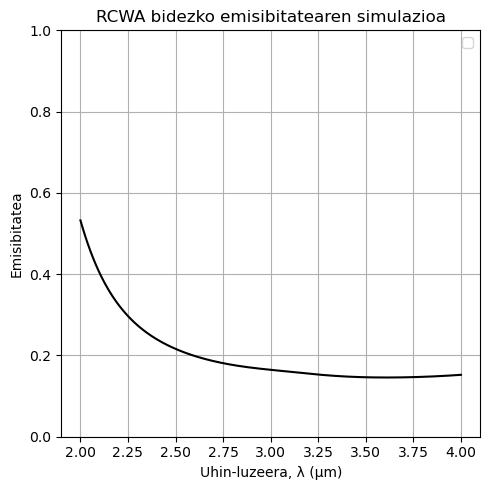

In [11]:
E_TM_plain = 1 - np.array(R_TM_plain)

plt.figure(figsize=(5,5))
plt.plot(wavelength, E_TM_plain, color="black")

plt.xlabel("Uhin-luzeera, λ (μm)")
plt.ylabel("Emisibitatea")
plt.legend()
plt.grid(True)
plt.title("RCWA bidezko emisibitatearen simulazioa")
plt.ylim(0,1)

plt.tight_layout()

# Guardar en PNG
plt.savefig("emisibitatea.png", dpi=300, bbox_inches="tight")

plt.show()

C:\Users\Alvaro\AppData\Local\Temp\ipykernel_16540\2519484237.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


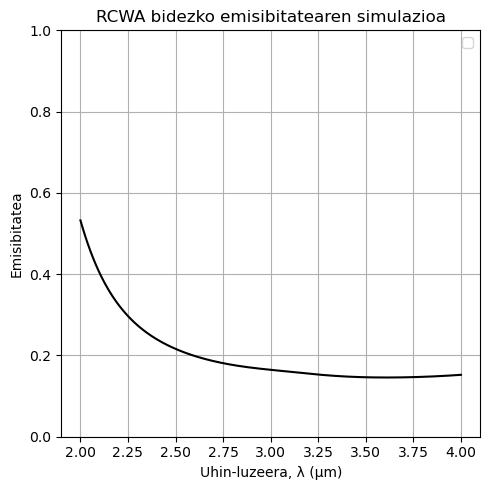

In [63]:
E_TM_plain = 1 - np.array(R_TM_plain)

plt.figure(figsize=(5,5))
plt.plot(wavelength, E_TM_plain, color="black")

plt.xlabel("Uhin-luzeera, λ (μm)")
plt.ylabel("Emisibitatea")
plt.legend()
plt.grid(True)
plt.title("RCWA bidezko emisibitatearen simulazioa")
plt.ylim(0,1)

plt.tight_layout()

# Guardar en PNG
# plt.savefig("emisibitateaSi.png", dpi=300, bbox_inches="tight")

plt.show()